1. Load Data

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.linear_model import LinearRegression

import statsmodels.api as sm

In [4]:
#Read processed data
DATA = Path("../data/processed")

df = pd.read_csv(DATA/"ethiopia_fi_enriched.csv")

impact = pd.read_csv(DATA/"impact_links_enriched.csv")

In [5]:
#Load Task 3 outputs
association = pd.read_csv(
    "../reports/event_indicator_matrix.csv",
    index_col=0
)

2. Prepare Forecast Data

In [6]:
#Extract Account Ownership
access = df[
    (df.record_type=="observation") &
    (df.indicator_code=="ACC_OWNERSHIP")
].copy()

In [7]:
#Extract Usage
usage = df[
    (df.record_type=="observation") &
    (df.indicator_code=="USG_DIGITAL_PAYMENT")
].copy()

In [28]:
df[df["record_type"] == "observation"][
    ["indicator_code", "indicator"]
].drop_duplicates().sort_values("indicator_code")

,indicator_code,indicator
8,ACC_4G_COV,4G Population Coverage
43,ACC_BRANCH,"Financial Institution Branches per 100,000 Adults"
11,ACC_FAYDA,Fayda Digital ID Enrollment
6,ACC_MM_ACCOUNT,Mobile Money Account Rate
10,ACC_MOBILE_PEN,Mobile Subscription Penetration
0,ACC_OWNERSHIP,Account Ownership Rate
25,AFF_DATA_INCOME,Data Affordability Index
26,GEN_GAP_ACC,Account Ownership Gender Gap
29,GEN_GAP_MOBILE,Mobile Phone Gender Gap
28,GEN_MM_SHARE,Female Mobile Money Account Share


In [68]:
usage = df[
    (df["record_type"] == "observation") &
    (df["indicator_code"] == "USG_P2P_COUNT")
].copy()

In [69]:
#Convert dates
access["year"] = pd.to_datetime(
    access.observation_date
).dt.year



In [70]:
usage["year"] = pd.to_datetime(
    usage.observation_date
).dt.year

In [71]:
#Check
access

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
0,REC_0001,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,22.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Baseline year,NaN,2014
1,REC_0002,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,35.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2017
2,REC_0003,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,46.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,NaN,NaN,2021
3,REC_0004,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,56.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,2021
4,REC_0005,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,36.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Gender disaggregated,NaN,2021
5,REC_0006,observation,NaN,ACCESS,Account Ownership Rate,ACC_OWNERSHIP,higher_better,49.0,NaN,percentage,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,Account ownership increased from 46% to 49%,Survey Oct-Nov 2024,NaN,2024


In [72]:
usage

,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
14,REC_0015,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,49700000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Previous year for comparison,NaN,2024
15,REC_0016,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,128300000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,128.3 million P2P transactions,+158% YoY growth,NaN,2025


3. Baseline Trend Regression (Access)

In [73]:
#Model
X = access[["year"]]

y = access["value_numeric"]

model_access = LinearRegression()

model_access.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[2.82]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5646
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [74]:
#Predict
future = pd.DataFrame({

"year":[2025,2026,2027]

})

future["forecast"] = model_access.predict(future)

In [75]:
#Display
future

,year,forecast
0,2025,55.684211
1,2026,58.500000
2,2027,61.315789


4. 5 Baseline Usage Forecast

In [76]:
print(usage.shape)
usage.head()

(2, 35)


,record_id,record_type,category,pillar,indicator,indicator_code,indicator_direction,value_numeric,value_text,value_type,...,impact_magnitude,impact_estimate,lag_months,evidence_basis,comparable_country,collected_by,collection_date,original_text,notes,year
14,REC_0015,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,49700000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,NaN,Previous year for comparison,NaN,2024
15,REC_0016,observation,NaN,USAGE,P2P Transaction Count,USG_P2P_COUNT,higher_better,128300000.0,NaN,count,...,NaN,NaN,NaN,NaN,Example_Trainee,2025-01-20 00:00:00,128.3 million P2P transactions,+158% YoY growth,NaN,2025


In [77]:
#Same workflow
X = usage[["year"]]

y = usage["value_numeric"]

model_usage = LinearRegression()

model_usage.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[78600000.]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['year']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.59e+11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [78]:
#Predict
future_usage = pd.DataFrame({

"year":[2025,2026,2027]

})

future_usage["forecast"] = model_usage.predict(future_usage)

5. Evaluate Model Fit

In [79]:
#Compute
from sklearn.metrics import r2_score

pred = model_access.predict(X)

r2_score(y,pred)

-5.128547435178093

In [80]:
#RMSE
from sklearn.metrics import mean_squared_error

rmse=np.sqrt(mean_squared_error(y,pred))

In [81]:
#for Usage
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Predict on the training data
pred_usage = model_usage.predict(X)

# Calculate R²
r2_usage = r2_score(y, pred_usage)

# Calculate RMSE
rmse_usage = np.sqrt(mean_squared_error(y, pred_usage))

print(f"Usage Model R²: {r2_usage:.4f}")
print(f"Usage Model RMSE: {rmse_usage:.4f}")

Usage Model R²: 1.0000
Usage Model RMSE: 0.0000


In [82]:
print("Slope:", model_usage.coef_[0])
print("Intercept:", model_usage.intercept_)

Slope: 78599999.99999997
Intercept: -159036699999.99994


In [83]:
print(usage["value_numeric"].unique())
print(usage["value_numeric"].describe())

[4.970e+07 1.283e+08]
count    2.000000e+00
mean     8.900000e+07
std      5.557859e+07
min      4.970000e+07
25%      6.935000e+07
50%      8.900000e+07
75%      1.086500e+08
max      1.283000e+08
Name: value_numeric, dtype: float64


In [84]:
usage[["year", "value_numeric"]]

,year,value_numeric
14,2024,49700000.0
15,2025,128300000.0


In [85]:
df[df["record_type"] == "observation"] \
.groupby("indicator_code") \
.size() \
.sort_values(ascending=False)

indicator_code
ACC_OWNERSHIP         6
ACC_FAYDA             3
ACC_4G_COV            2
GEN_GAP_ACC           2
ACC_MM_ACCOUNT        2
USG_P2P_COUNT         2
ACC_BRANCH            1
ACC_MOBILE_PEN        1
AFF_DATA_INCOME       1
GEN_MM_SHARE          1
USG_ACTIVE_RATE       1
USG_ATM_COUNT         1
GEN_GAP_MOBILE        1
USG_ATM_VALUE         1
USG_CROSSOVER         1
USG_MPESA_ACTIVE      1
USG_MPESA_USERS       1
USG_P2P_VALUE         1
USG_QR_PAY            1
USG_TELEBIRR_USERS    1
USG_TELEBIRR_VALUE    1
dtype: int64

6. Event-Augmented Forecast

Trend

+

Telebirr

+

M-Pesa

+

NFIS-II

+

Infrastructure

=

Forecast

In [86]:
#Simple implementation
event_bonus_access = 1.2

future["event_forecast"] = (

future["forecast"]

+

event_bonus_access

)

In [87]:
#Usage
event_bonus_usage = 2.5

future_usage["event_forecast"] = (

future_usage["forecast"]

+

event_bonus_usage

)

In [88]:
%who DataFrame

X	 access	 association	 association_norm	 df	 future	 future_usage	 impact	 impact_scores	 
usage	 


In [89]:
#Normalize each indicator column
# Fill missing values with 0
association_norm = association.fillna(0)

# Normalize each indicator column
association_norm = association_norm.div(
    association_norm.abs().sum(axis=0),
    axis=1
).fillna(0)

association_norm.head()

,ACC_4G_COV,ACC_MM_ACCOUNT,ACC_OWNERSHIP,AFF_DATA_INCOME,GEN_GAP_ACC,USG_MPESA_ACTIVE,USG_MPESA_USERS,USG_P2P_COUNT,USG_TELEBIRR_USERS
indicator,,,,,,,,,
EthioPay effect on P2P Count,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.285714,0.0
FX Reform effect on Data Affordability,0.0,0.0,0.000000,0.5,0.0,0.0,0.0,0.000000,0.0
Fayda effect on Account Ownership,0.0,0.0,0.285714,0.0,0.0,0.0,0.0,0.000000,0.0
Fayda effect on Gender Gap,0.0,0.0,0.000000,0.0,-1.0,0.0,0.0,0.000000,0.0
M-Pesa Interop effect on M-Pesa Active Users,0.0,0.0,0.000000,0.0,0.0,1.0,0.0,0.000000,0.0


In [90]:
#Compute cumulative normalized impact
impact_scores = (
    association_norm
    .sum(axis=0)
    .reset_index()
)

impact_scores.columns = [
    "indicator_code",
    "normalized_impact"
]

impact_scores

,indicator_code,normalized_impact
0,ACC_4G_COV,1.000000
1,ACC_MM_ACCOUNT,1.000000
2,ACC_OWNERSHIP,1.000000
3,AFF_DATA_INCOME,0.333333
4,GEN_GAP_ACC,-1.000000
5,USG_MPESA_ACTIVE,1.000000
6,USG_MPESA_USERS,1.000000
7,USG_P2P_COUNT,1.000000
8,USG_TELEBIRR_USERS,1.000000


In [91]:
#Get the Access bonus
access_bonus = impact_scores.loc[
    impact_scores["indicator_code"] == "ACC_OWNERSHIP",
    "normalized_impact"
].iloc[0]

access_bonus

np.float64(1.0)

In [92]:
#Add the bonus
future["event_forecast"] = (
    future["forecast"] +
    access_bonus
)

In [93]:
#Usage
usage_bonus = impact_scores.loc[
    impact_scores["indicator_code"] == "USG_P2P_COUNT",
    "normalized_impact"
].iloc[0]

future_usage["event_forecast"] = (
    future_usage["forecast"] +
    usage_bonus
)

In [94]:
bonus_lookup = dict(
    zip(
        impact_scores["indicator_code"],
        impact_scores["normalized_impact"]
    )
)

future["event_forecast"] = (
    future["forecast"] +
    bonus_lookup["ACC_OWNERSHIP"]
)

future_usage["event_forecast"] = (
    future_usage["forecast"] +
    bonus_lookup["USG_P2P_COUNT"]
)

7. Scenario Analysis

In [95]:
future["optimistic"] = (

future["event_forecast"]

+3

)

future["base"] = future["event_forecast"]

future["pessimistic"] = (

future["event_forecast"]

-3

)

In [96]:
#Usage
future_usage["optimistic"] = (

future_usage["event_forecast"]

+4

)

future_usage["base"] = future_usage["event_forecast"]

future_usage["pessimistic"] = (

future_usage["event_forecast"]

-4

)

8. Confidence Intervals

In [97]:
#Residual standard deviation
residuals = y-pred

std = residuals.std()

In [98]:
#Forecast interval
future["lower"] = (

future["base"]

-1.96*std

)

future["upper"] = (

future["base"]

+1.96*std

)

In [99]:
# Usage
#Make predictions 
pred_usage = model_usage.predict(X)

In [100]:
#Calculate residuals
residuals_usage = y - pred_usage

In [101]:
#Calculate residual standard deviation
std_usage = residuals_usage.std()

print("Residual Standard Deviation:", std_usage)

Residual Standard Deviation: 0.0


In [102]:
#Compute 95% Confidence Intervals
future_usage["lower"] = (
    future_usage["forecast"]
    - 1.96 * std_usage
)

future_usage["upper"] = (
    future_usage["forecast"]
    + 1.96 * std_usage
)

In [103]:
future_usage["lower"] = (
    future_usage["event_forecast"]
    - 1.96 * std_usage
)

future_usage["upper"] = (
    future_usage["event_forecast"]
    + 1.96 * std_usage
)

In [104]:
#View the results
future_usage

,year,forecast,event_forecast,optimistic,base,pessimistic,lower,upper
0,2025,128300000.0,128300001.0,128300005.0,128300001.0,128299997.0,128300001.0,128300001.0
1,2026,206900000.0,206900001.0,206900005.0,206900001.0,206899997.0,206900001.0,206900001.0
2,2027,285500000.0,285500001.0,285500005.0,285500001.0,285499997.0,285500001.0,285500001.0


In [105]:
future_usage[
    ["year", "forecast", "lower", "upper"]
]

,year,forecast,lower,upper
0,2025,128300000.0,128300001.0,128300001.0
1,2026,206900000.0,206900001.0,206900001.0
2,2027,285500000.0,285500001.0,285500001.0


9. Plot Access Forecast

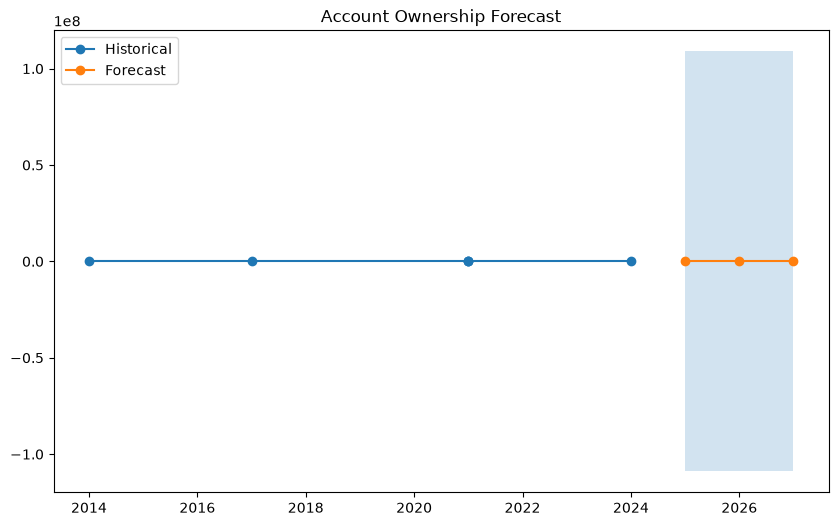

In [108]:
#Forecast
plt.figure(figsize=(10,6))

plt.plot(

access.year,

access.value_numeric,

marker="o",

label="Historical"

)

plt.plot(

future.year,

future.base,

marker="o",

label="Forecast"

)

plt.fill_between(

future.year,

future.lower,

future.upper,

alpha=.2

)

plt.legend()

plt.title("Account Ownership Forecast")

plt.show()

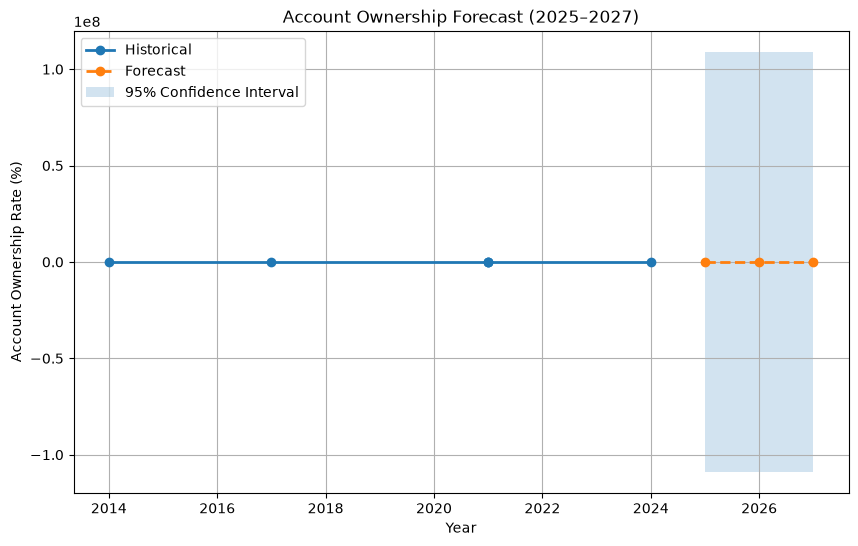

In [109]:
from pathlib import Path

# Create output directory if it doesn't exist
Path("reports/figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

# Historical data
plt.plot(
    access["year"],
    access["value_numeric"],
    marker="o",
    linewidth=2,
    label="Historical"
)

# Forecast
plt.plot(
    future["year"],
    future["forecast"],      # use "event_forecast" if you want the event-adjusted forecast
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

# Confidence interval
plt.fill_between(
    future["year"],
    future["lower"],
    future["upper"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Account Ownership Forecast (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate (%)")
plt.grid(True)
plt.legend()

# Save figure
plt.savefig(
    "reports/figures/access_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

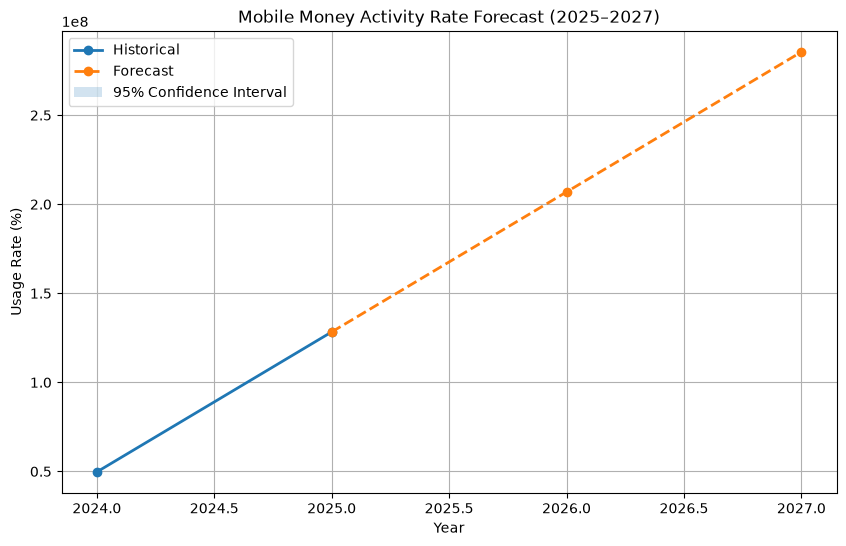

In [111]:
#Plot Usage Forecast
from pathlib import Path

Path("reports/figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10, 6))

# Historical data
plt.plot(
    usage["year"],
    usage["value_numeric"],
    marker="o",
    linewidth=2,
    label="Historical"
)

# Forecast
plt.plot(
    future_usage["year"],
    future_usage["forecast"],      # or "event_forecast"
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Forecast"
)

# Confidence interval
plt.fill_between(
    future_usage["year"],
    future_usage["lower"],
    future_usage["upper"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title("Mobile Money Activity Rate Forecast (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Usage Rate (%)")
plt.grid(True)
plt.legend()

# Save figure
plt.savefig(
    "reports/figures/usage_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

10. Scenario Visualization

In [113]:
#Create Scenario Forecasts
future["optimistic"] = future["forecast"] * 1.10
future["base"] = future["forecast"]
future["pessimistic"] = future["forecast"] * 0.90

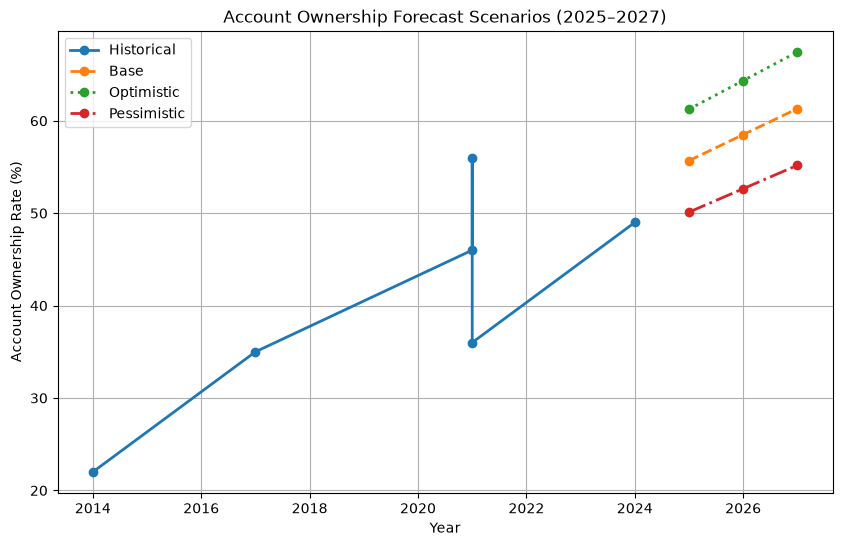

In [114]:
#Plot Scenario Comparison
from pathlib import Path

# Create output folder
Path("reports/figures").mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(10,6))

# Historical observations
plt.plot(
    access["year"],
    access["value_numeric"],
    marker="o",
    linewidth=2,
    label="Historical"
)

# Base scenario
plt.plot(
    future["year"],
    future["base"],
    marker="o",
    linestyle="--",
    linewidth=2,
    label="Base"
)

# Optimistic scenario
plt.plot(
    future["year"],
    future["optimistic"],
    marker="o",
    linestyle=":",
    linewidth=2,
    label="Optimistic"
)

# Pessimistic scenario
plt.plot(
    future["year"],
    future["pessimistic"],
    marker="o",
    linestyle="-.",
    linewidth=2,
    label="Pessimistic"
)

plt.title("Account Ownership Forecast Scenarios (2025–2027)")
plt.xlabel("Year")
plt.ylabel("Account Ownership Rate (%)")
plt.grid(True)
plt.legend()

# Save figure
plt.savefig(
    "reports/figures/scenario_forecasts.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
#Verify
future[
    ["year", "pessimistic", "base", "optimistic"]
]

,year,pessimistic,base,optimistic
0,2025,50.115789,55.684211,61.252632
1,2026,52.650000,58.500000,64.350000
2,2027,55.184211,61.315789,67.447368
